# Move your experiment to a TPU

Runnable locally on CPU or on a Cloud TPU VM.

- Verify the device of a completed prediction and its independent numerical reference.
- Provision a hosted TPU notebook or single-host Google Cloud TPU VM and verify device discovery.
- Launch an explicit TPU target path over SSH that fails when TPU is unavailable, then clean up the resource.
- Run subsequent course lessons and companion labs on TPU in parallel with local CPU practice.

Your notebook imports JAX successfully, but is the prediction actually running on a TPU? We will build a portable device check with an independent numerical answer, then require the requested backend so an unavailable accelerator cannot silently become a successful CPU demonstration.

## The idea

Moving an experiment to a TPU gives us two questions: did it calculate the intended result, and did it actually execute on the requested device? We answer the first with an independent numerical reference and the second with an observed device receipt.

## Check arithmetic and placement separately

Consider a prediction that adds a scalar bias after a dot product. Reducing the bias by $0.25$ should reduce every prediction by $0.25$, whatever compatible device performs the computation. That is a numerical invariant you can derive before running.

Now inspect where the completed result resides. A correct NumPy comparison on CPU does not show that a TPU was selected. Conversely, a TPU device label does not show that the formula or input data was correct. Keep both checks.

Wait for the result before recording completion or timing. A returned array handle can precede finished device work. Preserve the requested platform, observed platform, environment and error tolerance alongside the values.

### Pause and reason

The values match NumPy but the requested TPU run reports a CPU result. Which part passed?

<details><summary>Compare your reasoning</summary>

The arithmetic comparison passed. The requested placement did not. Investigate runtime/device selection instead of treating the numerical match as TPU validation.

</details>

## Carry a prediction, not just an installation

We will move one small function between runtimes: a matrix-vector prediction with a scalar bias. Each row is an observation; three columns are three features. The weights are fixed so we can calculate the answer independently. For the first row, $[0,1/8,2/8]$, the prediction is $0-1/32+1/4+1/8=11/32$. A working package import is useful, but it is separate from where this computation finished.

$$
\hat y_i=\sum_{j=1}^{3}x_{ij}w_j+b,\qquad X\in\mathbb{R}^{8\times3},\quad w\in\mathbb{R}^{3},\quad b=1/8
$$

## Establish the CPU reference first

Save the assembled code as main.py in your course workspace and run it in a fresh process. By default COURSE_EXPECT_PLATFORM is cpu. The program selects that backend explicitly, places both inputs on its first device and waits for the compiled prediction to finish. NumPy independently calculates the same arithmetic. Keep the environment report and predictions.

The tolerance allows small floating-point differences; a successful comparison means this prediction agrees within that tolerance. It is separate from accuracy for a larger model. We use float32 inputs deliberately. Implicit dtype changes and reduced-precision matrix multiplication should be separate experiments after the placement check.

**Run the CPU reference**

```bash
# Run run the cpu reference using the course Python environment
python main.py
```

**Expected:** The report names cpu, shape [8], float32, a completed output device and a small maximum absolute error. The first prediction is 0.34375.

## Get a TPU running: hosted notebook or Google Cloud TPU VM

You do not need to wait until the end of the course to use a TPU. There are two practical ways to get a TPU running right now so you can run experiments alongside the course:

1. Hosted notebook TPU (Google Colab or Kaggle): open Runtime -> Change runtime type, select a TPU accelerator (such as TPU v5e-1 or v6e-1), and restart the kernel before importing JAX so the process does not lock in a CPU backend.

2. Google Cloud single-host TPU VM: install the Google Cloud CLI on your laptop, authenticate with `gcloud auth login`, and create a single-host TPU VM (such as `v5litepod-1`, `v5litepod-4` or `v6e-1`) in an approved project and zone. Wait until the VM state is `READY`. Remember that a Cloud TPU VM is a billable machine whose lifetime is separate from your Python process: when Python exits, the VM keeps running until you delete it or its bounded max-run-duration expires.

**From your laptop: provision a single-host Cloud TPU VM and check READY state**

```bash
# From your laptop: provision a single-host Cloud TPU VM and check READY state
export PROJECT_ID="REPLACE_WITH_YOUR_PROJECT"
export ZONE="us-central1-a"
export TPU_NAME="jax-course-tpu-01"
gcloud compute tpus tpu-vm create "$TPU_NAME" \
  --project="$PROJECT_ID" --zone="$ZONE" \
  --accelerator-type="v5litepod-1" --version="v2-alpha-tpuv5-lite"
gcloud compute tpus tpu-vm describe "$TPU_NAME" \
  --project="$PROJECT_ID" --zone="$ZONE" --format="value(state)"
```

**Expected:** The Cloud TPU VM is created in your project/zone and describe prints READY. For bounded Flex-start templates or queued resources, see the TPU and Google Cloud practical guide.

**Inside the TPU VM or hosted TPU runtime: install JAX for TPU and verify devices**

```bash
# Run inside the tpu vm or hosted tpu runtime: install jax for tpu and verify devices using the course Python environment
python3 -m venv .venv
.venv/bin/python -m pip install --upgrade "jax[tpu]" numpy
.venv/bin/python -c "import jax; print(jax.default_backend(), jax.devices('tpu'))"
```

**Expected:** The TPU environment installs compatible JAX and libtpu packages and prints tpu with the visible TpuDevice list. Record the resolved versions; installation alone is not the execution check.

## Launch the experiment on TPU, retrieve the receipt, and delete the VM

Once your TPU environment is ready, copy `main.py` to the TPU host, launch it in a fresh process with `COURSE_EXPECT_PLATFORM=tpu` and `JAX_PLATFORMS=tpu`, and copy the output report back to your laptop. The call to `jax.devices(expected)` requests TPU explicitly and fails immediately if the TPU backend is unavailable.

This is a single-controller, single-device placement check even if the runtime exposes four or eight chips. Multi-chip sharding on one host and multi-host launches with `jax.distributed.initialize()` are covered in the virtual-CPU and distributed lessons. As soon as you copy your evidence back to your laptop, delete the Cloud TPU VM and verify that the instance list is empty.

**Require TPU execution inside an active TPU session**

```bash
# Require TPU execution inside an active TPU session
COURSE_EXPECT_PLATFORM=tpu JAX_PLATFORMS=tpu python main.py
```

**Expected:** On a functioning TPU runtime the report names tpu and all assertions pass. An unavailable TPU must raise an error instead of producing a CPU success report.

**From your laptop: copy main.py, launch over SSH, copy back evidence, and delete the TPU VM**

```bash
# From your laptop: copy main.py, launch over SSH, copy back evidence, and delete the TPU VM
gcloud compute tpus tpu-vm scp main.py "$TPU_NAME:~/main.py" --project="$PROJECT_ID" --zone="$ZONE"
gcloud compute tpus tpu-vm ssh "$TPU_NAME" --project="$PROJECT_ID" --zone="$ZONE" \
  --command="COURSE_EXPECT_PLATFORM=tpu JAX_PLATFORMS=tpu .venv/bin/python ~/main.py | tee ~/tpu-report.txt"
gcloud compute tpus tpu-vm scp "$TPU_NAME:~/tpu-report.txt" ./tpu-report.txt --project="$PROJECT_ID" --zone="$ZONE"
gcloud compute tpus tpu-vm delete "$TPU_NAME" --project="$PROJECT_ID" --zone="$ZONE" --quiet
gcloud compute tpus tpu-vm list --project="$PROJECT_ID" --zone="$ZONE"
```

**Expected:** The remote command runs on the TPU VM, writes tpu-report.txt locally, deletes the TPU VM, and confirms no running TPU VM remains.

## Run the rest of the course on TPU in parallel

Use this same launch pattern in parallel with every phase that follows. Every authored lesson in the course provides a standalone script under `exercises/<lesson-id>.py` (and a notebook under `exercises/<lesson-id>.ipynb`). As you work through Arrays (Phase 01), Transforms (Phase 02), State (Phase 03), Optimization (Phase 04), Networks (Phase 05) and Recovery (Phase 06), run the CPU reference locally first, then upload the workspace or script to your TPU runtime and run it with `JAX_PLATFORMS=tpu`.

In parallel with the early phases, work through the two standalone TPU guides included in the course workspace (`jax-tpu-gcp.zip`): use `resources/tpu-gcp/launch.py` to practice supervised TPU job lifecycles and checkpoint recovery, and use `resources/tpu-gcp/precision_profile.py` to measure BF16/INT8 numerical error and capture XProf device traces before you scale up to full Transformers and distributed training.

**Run any course lesson script and the companion TPU labs on a TPU host**

```bash
# Run any course lesson script and the companion TPU labs on a TPU host
JAX_PLATFORMS=tpu .venv/bin/python exercises/arrays-01.py
.venv/bin/python resources/tpu-gcp/launch.py --platform tpu --run-dir runs/tpu-first --steps 8 --timeout 180
.venv/bin/python resources/tpu-gcp/precision_profile.py --platform tpu --run-dir runs/precision-tpu --steps 20 --trace
```

**Expected:** The lesson script and companion TPU labs run on the TPU backend, writing verifiable device receipts, checkpoints, numerical error reports and XProf trace files.

## Diagnose the boundary that failed

If import fails, check the interpreter and installation. If explicit backend selection fails, check whether you are in the intended runtime and whether its TPU service is available. If device placement succeeds but the independent comparison fails, inspect shapes, dtype, precision and the arithmetic. Do not widen tolerance just to hide a large error.

An old notebook kernel may retain an initialized CPU backend or stale variables. Restart it, set runtime choices before the first device operation and run every cell. A CPU plot from the recorded course run remains a CPU plot when viewed on a machine that happens to have TPU access; only a fresh recorded execution supplies new evidence.

## Choose the requested platform

Add this block to main.py after the preceding block. Run the assembled file in a fresh process.

In [1]:
# Step 1 — Choose the requested platform: Keep the requested backend, observed output placement and...
# Import os for this computation.
import os
import json
import platform
import numpy as np
import jax
import jax.numpy as jnp

Keep the requested backend, observed output placement and independent arithmetic check together in the final report.

## Place inputs and compare a completed prediction

Add this block to main.py after the preceding block. Run the assembled file in a fresh process.

In [2]:
# Step 2 — Place inputs and compare a completed prediction: Keep the requested backend, observed output placement and...
expected = os.environ.get('COURSE_EXPECT_PLATFORM', 'cpu')
# Guard input contract (`expected not in {'cpu', 'tpu'}`) and fail fast if violated.
if expected not in {'cpu', 'tpu'}:
    raise ValueError('COURSE_EXPECT_PLATFORM must be cpu or tpu')
# Selecting a requested backend must fail when it is unavailable.
devices = jax.devices(expected)
# Assert invariant `devices and all(d.platform == expected for d in devices)` holds
assert devices and all(d.platform == expected for d in devices)
# Construct and reshape `x_host` into the target tensor dimensions.
x_host = np.arange(24, dtype=np.float32).reshape(8, 3) / 8
# Compute `w_host` from `np.array([0.5, -0.25, 1.0], dtype=np.float32)`
w_host = np.array([0.5, -0.25, 1.0], dtype=np.float32)
# Place `x` explicitly onto the target JAX device.
x = jax.device_put(x_host, devices[0])
# Place `w` explicitly onto the target JAX device.
w = jax.device_put(w_host, devices[0])
# Wrap with `jax.jit` (`predict`) so XLA traces and compiles the function.
predict = jax.jit(lambda a, b: a @ b + jnp.float32(0.125))
# Run `predict` to compute `y`.
y = predict(x, w)
# Synchronize host execution until asynchronous device computation completes.
y.block_until_ready()
# Cast or evaluate `reference` in explicit floating-point precision.
reference = x_host @ w_host + np.float32(0.125)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(np.asarray(y), reference, rtol=1e-5, atol=1e-5)
# Assert invariant `{d.platform for d in y.devices()} == {expected}` holds
assert {d.platform for d in y.devices()} == {expected}
# Convert `report` to a host NumPy array for inspection or verification.
report = dict(expected=expected, output_devices=[str(d) for d in y.devices()],
              platform=next(iter(y.devices())).platform, jax=jax.__version__,
              python=platform.python_version(), shape=list(y.shape), dtype=str(y.dtype),
              max_absolute_error=float(np.max(np.abs(np.asarray(y)-reference))),
              process_index=jax.process_index(), process_count=jax.process_count())
# Print diagnostic summary of the computed outputs.
print(json.dumps(report, indent=2))
# Print diagnostic summary of the computed outputs.
print('Completed prediction:', np.asarray(y).tolist())

Keep the requested backend, observed output placement and independent arithmetic check together in the final report.

## Step 3: Verify invariants on the completed state

Run the final shape and numerical assertions to confirm the state built in Steps 1 and 2.

In [3]:
              max_absolute_error=float(np.max(np.abs(np.asarray(y)-reference))),
              process_index=jax.process_index(), process_count=jax.process_count())

Checking these invariants confirms the computation is ready for the full worked experiment.

## Run the example

In [4]:
# Step 1 — Choose the requested platform: Keep the requested backend, observed output placement and...
# Import os for this computation.
import os
import json
import platform
import numpy as np
import jax
import jax.numpy as jnp

# Step 2 — Place inputs and compare a completed prediction: Keep the requested backend, observed output placement and...
expected = os.environ.get('COURSE_EXPECT_PLATFORM', 'cpu')
# Guard input contract (`expected not in {'cpu', 'tpu'}`) and fail fast if violated.
if expected not in {'cpu', 'tpu'}:
    raise ValueError('COURSE_EXPECT_PLATFORM must be cpu or tpu')
# Selecting a requested backend must fail when it is unavailable.
devices = jax.devices(expected)
# Assert invariant `devices and all(d.platform == expected for d in devices)` holds
assert devices and all(d.platform == expected for d in devices)
# Construct and reshape `x_host` into the target tensor dimensions.
x_host = np.arange(24, dtype=np.float32).reshape(8, 3) / 8
# Compute `w_host` from `np.array([0.5, -0.25, 1.0], dtype=np.float32)`
w_host = np.array([0.5, -0.25, 1.0], dtype=np.float32)
# Place `x` explicitly onto the target JAX device.
x = jax.device_put(x_host, devices[0])
# Place `w` explicitly onto the target JAX device.
w = jax.device_put(w_host, devices[0])
# Wrap with `jax.jit` (`predict`) so XLA traces and compiles the function.
predict = jax.jit(lambda a, b: a @ b + jnp.float32(0.125))
# Run `predict` to compute `y`.
y = predict(x, w)
# Synchronize host execution until asynchronous device computation completes.
y.block_until_ready()
# Cast or evaluate `reference` in explicit floating-point precision.
reference = x_host @ w_host + np.float32(0.125)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(np.asarray(y), reference, rtol=1e-5, atol=1e-5)
# Assert invariant `{d.platform for d in y.devices()} == {expected}` holds
assert {d.platform for d in y.devices()} == {expected}
# Convert `report` to a host NumPy array for inspection or verification.
report = dict(expected=expected, output_devices=[str(d) for d in y.devices()],
              platform=next(iter(y.devices())).platform, jax=jax.__version__,
              python=platform.python_version(), shape=list(y.shape), dtype=str(y.dtype),
              max_absolute_error=float(np.max(np.abs(np.asarray(y)-reference))),
              process_index=jax.process_index(), process_count=jax.process_count())
# Print diagnostic summary of the computed outputs.
print(json.dumps(report, indent=2))
# Print diagnostic summary of the computed outputs.
print('Completed prediction:', np.asarray(y).tolist())

{
  "expected": "cpu",
  "output_devices": [
    "TFRT_CPU_0"
  ],
  "platform": "cpu",
  "jax": "0.9.2",
  "python": "3.14.3",
  "shape": [
    8
  ],
  "dtype": "float32",
  "max_absolute_error": 0.0,
  "process_index": 0,
  "process_count": 1
}
Completed prediction: [0.34375, 0.8125, 1.28125, 1.75, 2.21875, 2.6875, 3.15625, 3.625]


Expected: The recorded CPU reference predicts [0.34375, 0.8125, 1.28125, 1.75, 2.21875, 2.6875, 3.15625, 3.625]. Its report names the actual output device. There is no recorded TPU result.

## The same prediction checked two ways

Predict: Should the JAX line overlap the independent NumPy points, and would overlap alone prove TPU execution?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: The same prediction checked two ways
# Convert `visual_data` to a host NumPy array for inspection or verification.
visual_data={'kind':'line','x':list(range(8)),'xlabel':'observation row','ylabel':'prediction','series':[{'label':'JAX: '+expected,'y':np.asarray(y).tolist()},{'label':'NumPy reference','y':reference.tolist()}]}

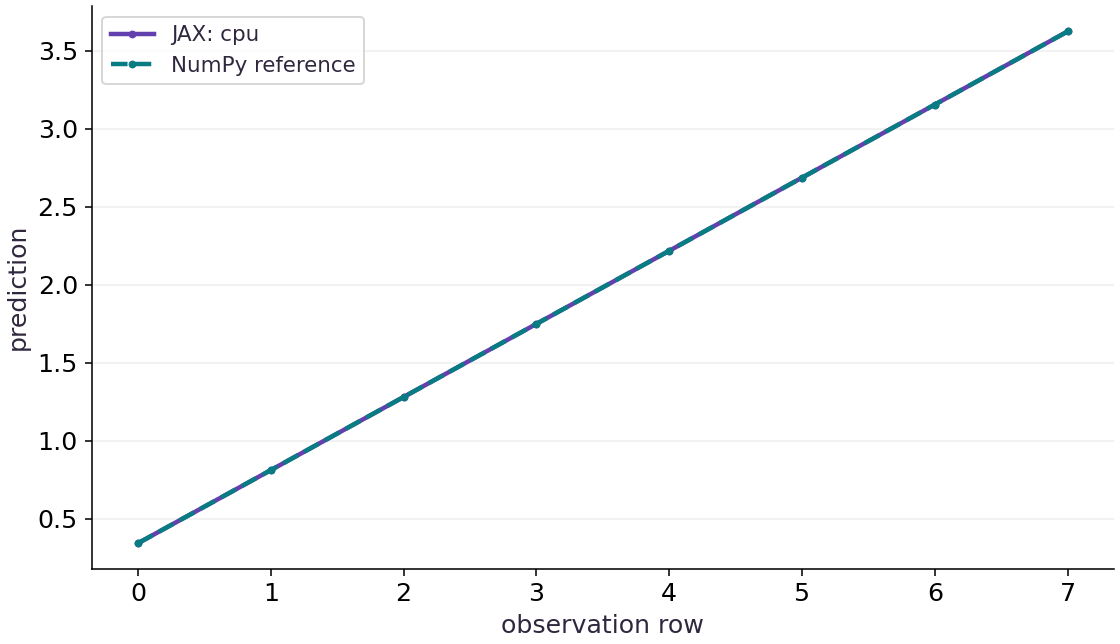

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis is the observation row index, starting at $0$. The vertical axis is the scalar prediction. The two series use the same inputs and weights: one comes from the completed JAX array, the other from NumPy. They overlap in this recorded CPU example. The first value is $11/32$; the constant rise of $15/32$ follows from increasing every feature by $3/8$ while the weights sum to $5/4$.

### Connect it to the computation

The line is a check of arithmetic and ordering for these eight observations. Read the printed platform report to determine placement; a curve cannot identify the device that produced it. The changed-bias exercise translates this line downward, while row reversal changes the order. This recorded figure comes from the CPU path and carries no TPU timing or correctness claim.

## Reject a mismatched report

Predict: Would a correct numeric answer be enough if the report says CPU but the requested target is TPU?

In [7]:
# Experiment — Reject a mismatched report: Numerical agreement and requested placement are separate...
def verify_report(record, required):
    # Guard input contract (`record['platform'] != required or record['expected'] != required`) and fail fast if violated.
    if record['platform'] != required or record['expected'] != required:
        raise ValueError('requested and observed platform disagree')
    # Guard input contract (`record['shape'] != [8] or record['dtype'] != 'float32'`) and fail fast if violated.
    if record['shape'] != [8] or record['dtype'] != 'float32':
        raise ValueError('prediction contract changed')
    # Return `True` to the caller.
    return True
# Assert invariant `verify_report(report, expected)` holds
assert verify_report(report, expected)
# Compute `wrong` from `{**report, 'platform': 'cpu' if expected == 'tpu' el...`
wrong = {**report, 'platform': 'cpu' if expected == 'tpu' else 'tpu'}
# Run the boundary check and catch the expected exception:
try:
    verify_report(wrong, expected)
except ValueError:
    print('Mismatched platform report rejected.')
else:
    raise AssertionError('a mismatched report was accepted')

Expected: The deliberately inconsistent report raises ValueError; the actual report passes.

Numerical agreement and requested placement are separate requirements. This experiment tests report validation; the main program performs the actual backend selection and array-placement check.

## Your exercise

Predict the effect of replacing the bias by minus one quarter. Run a second compiled prediction on the selected device. Compare against the original prediction plus the expected constant shift and an independent NumPy calculation.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.jit(fn) / @jax.jit` — Traces `fn` with abstract shapes and compiles a fused XLA executable cached by input shape and dtype.
- `jax.block_until_ready(output)` — Synchronizes with the accelerator/CPU device so asynchronous dispatch finishes before wall-clock timing.

**Step-by-step implementation plan:**
1. Wrap with `jax.jit` (`changed_predict`) so XLA traces and compiles the function.
2. Run `changed_predict` to compute `changed`.
3. Synchronize host execution until asynchronous device computation completes.
4. Convert `` to a host NumPy array for inspection or verification.
5. Convert `` to a host NumPy array for inspection or verification.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Predict the effect of replacing the bias by minus one quarter.
# Wrap with `jax.jit` (`changed_predict`) so XLA traces and compiles the function.
changed_predict = jax.jit(...)  # TODO: compute changed_predict
# Run `changed_predict` to compute `changed`.
changed = changed_predict(...)  # TODO: compute changed
# Synchronize host execution until asynchronous device computation completes.
changed.block_until_ready()
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(np.asarray(changed), reference - 0.375, atol=1e-5, rtol=1e-5)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(np.asarray(changed), x_host @ w_host - 0.25, atol=1e-5, rtol=1e-5)
# Assert invariant `{d.platform for d in changed.devices()} == {expected}` holds
assert {d.platform for d  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
print('Changed bias, first prediction:', float(changed[0]))
```

In [8]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Predict the effect of replacing the bias by minus one quarter.
# Wrap with `jax.jit` (`changed_predict`) so XLA traces and compiles the function.
# changed_predict = jax.jit(...)  # TODO: compute changed_predict
# Run `changed_predict` to compute `changed`.
# changed = changed_predict(...)  # TODO: compute changed
# Synchronize host execution until asynchronous device computation completes.
# changed.block_until_ready()
# Convert `` to a host NumPy array for inspection or verification.
# np.testing.assert_allclose(np.asarray(changed), reference - 0.375, atol=1e-5, rtol=1e-5)
# Convert `` to a host NumPy array for inspection or verification.
# np.testing.assert_allclose(np.asarray(changed), x_host @ w_host - 0.25, atol=1e-5, rtol=1e-5)
# Assert invariant `{d.platform for d in changed.devices()} == {expected}` holds
# assert {d.platform for d  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
# print('Changed bias, first prediction:', float(changed[0]))

## Reference solution

Try your own implementation first.

In [9]:
# Exercise solution: Predict the effect of replacing the bias by minus one quarter.
# Wrap with `jax.jit` (`changed_predict`) so XLA traces and compiles the function.
changed_predict = jax.jit(lambda a, b: a @ b - jnp.float32(0.25))
# Run `changed_predict` to compute `changed`.
changed = changed_predict(x, w)
# Synchronize host execution until asynchronous device computation completes.
changed.block_until_ready()
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(np.asarray(changed), reference - 0.375, atol=1e-5, rtol=1e-5)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(np.asarray(changed), x_host @ w_host - 0.25, atol=1e-5, rtol=1e-5)
# Assert invariant `{d.platform for d in changed.devices()} == {expected}` holds
assert {d.platform for d in changed.devices()} == {expected}
# Print the observed values to compare against the expected result.
print('Changed bias, first prediction:', float(changed[0]))

## Test row order without changing the model · Transfer

Reverse the observation rows and predict the result order before execution. Verify the first and last values, the complete vector and device placement. Explain why this is a stronger check than only comparing the vector sum.

Hint: A row-wise affine prediction commutes with row permutation. A sum would conceal an ordering bug.

### How to write: Test row order without changing the model — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `Mesh + PartitionSpec + NamedSharding` — Maps logical tensor axes onto physical device mesh axes for SPMD data, tensor, or pipeline parallelism.
- `jax.block_until_ready(output)` — Synchronizes with the accelerator/CPU device so asynchronous dispatch finishes before wall-clock timing.

**Step-by-step implementation plan:**
1. Run `predict` to compute `reversed_y`.
2. Synchronize host execution until asynchronous device computation completes.
3. Convert `` to a host NumPy array for inspection or verification.
4. Assert invariant `{d.platform for d in reversed_y.devices()} == {expected}` holds
5. Check numerical equivalence within tolerance: `np.isclose(float(reversed_y[0]), 3.625)`

**Starter code scaffold (fill in the TODOs):**

```python
# Test row order without changing the model (Transfer): Reversing rows should reverse predictions because each...
reversed_x = jax.device_put(...)  # TODO: compute reversed_x
# Run `predict` to compute `reversed_y`.
reversed_y = predict(...)  # TODO: compute reversed_y
# Synchronize host execution until asynchronous device computation completes.
reversed_y.block_until_ready()
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(np.asarray(reversed_y), reference[::-1], atol=1e-5, rtol=1e-5)
# Assert invariant `{d.platform for d in reversed_y.devices()} == {expected}` holds
assert {d.platform for d  # TODO: complete assertion check
# Check numerical equivalence within tolerance: `np.isclose(float(reversed_y[0]), 3.625)`
assert np.isclose(float(reversed_y[0]), 3.625)  # TODO: complete assertion check
# Check numerical equivalence within tolerance: `np.isclose(float(reversed_y[-1]), 0.34375)`
assert np.isclose(float(reversed_y[-1]), 0.34375)  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
print('Row reversal preserved values and requested placement.')
```

In [10]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Test row order without changing the model (Transfer): Reversing rows should reverse predictions because each...
# reversed_x = jax.device_put(...)  # TODO: compute reversed_x
# Run `predict` to compute `reversed_y`.
# reversed_y = predict(...)  # TODO: compute reversed_y
# Synchronize host execution until asynchronous device computation completes.
# reversed_y.block_until_ready()
# Convert `` to a host NumPy array for inspection or verification.
# np.testing.assert_allclose(np.asarray(reversed_y), reference[::-1], atol=1e-5, rtol=1e-5)
# Assert invariant `{d.platform for d in reversed_y.devices()} == {expected}` holds
# assert {d.platform for d  # TODO: complete assertion check
# Check numerical equivalence within tolerance: `np.isclose(float(reversed_y[0]), 3.625)`
# assert np.isclose(float(reversed_y[0]), 3.625)  # TODO: complete assertion check
# Check numerical equivalence within tolerance: `np.isclose(float(reversed_y[-1]), 0.34375)`
# assert np.isclose(float(reversed_y[-1]), 0.34375)  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
# print('Row reversal preserved values and requested placement.')

## Reference reasoning

Reversing rows should reverse predictions because each observation is evaluated independently. Matching a sum would not reveal a misplaced or reordered prediction.

In [11]:
# Test row order without changing the model (Transfer): Reversing rows should reverse predictions because each...
reversed_x = jax.device_put(x_host[::-1].copy(), devices[0])
# Run `predict` to compute `reversed_y`.
reversed_y = predict(reversed_x, w)
# Synchronize host execution until asynchronous device computation completes.
reversed_y.block_until_ready()
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(np.asarray(reversed_y), reference[::-1], atol=1e-5, rtol=1e-5)
# Assert invariant `{d.platform for d in reversed_y.devices()} == {expected}` holds
assert {d.platform for d in reversed_y.devices()} == {expected}
# Check numerical equivalence within tolerance: `np.isclose(float(reversed_y[0]), 3.625)`
assert np.isclose(float(reversed_y[0]), 3.625)
# Check numerical equivalence within tolerance: `np.isclose(float(reversed_y[-1]), 0.34375)`
assert np.isclose(float(reversed_y[-1]), 0.34375)
# Print the observed values to compare against the expected result.
print('Row reversal preserved values and requested placement.')

## Checkpoint

The values match NumPy, but the output array is on CPU when the requested platform was TPU. What has been demonstrated?

1. The TPU installation and its execution are validated.
2. The arithmetic matches the reference on the fallback CPU backend, so the requested TPU backend was not active.
3. The model must be numerically wrong.

## Diagnose

Read the first failing boundary: interpreter/import, explicit backend discovery, output placement or numerical comparison. Keep the original error and requested platform in the report. Restart a stale notebook kernel before trying the target again.

## Evidence

Keep separate CPU and TPU reports with requested/observed platform, package versions, completed predictions, NumPy error and changed-bias and row-permutation checks. Until the target command succeeds, TPU execution remains unverified.

## Carry forward

- Provision a hosted TPU runtime or single-host Cloud TPU VM early and run course experiments in parallel with your CPU baseline.
- Check an actual completed array, not only the installed package.
- Request TPU explicitly so its absence produces an error, and delete Cloud TPU VMs after copying your evidence.

## Primary references

- [JAX installation and TPU support](https://docs.jax.dev/en/latest/installation.html)
- [Manage Cloud TPU VMs with gcloud](https://docs.cloud.google.com/tpu/docs/managing-tpus-tpu-vm)
- [Course guide: From a laptop experiment to a TPU training run](https://www.tahabouhsine.com/jaxpathways/tpu-gcp.html)
- [Course guide: TPU generations, precision and profiling](https://www.tahabouhsine.com/jaxpathways/tpu-performance.html)
- [JAX device placement](https://docs.jax.dev/en/latest/sharded-computation.html)